In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
az. style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300)

In [3]:
np.random.seed(123)
trials = 4
theta_real = 0.35 # unknown value in a real experiment
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([1, 1, 0, 0], dtype=int64)

In [4]:
with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=theta,observed=data)
    idata = pm.sample(draws=1000, chains=4, tune=1000, random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

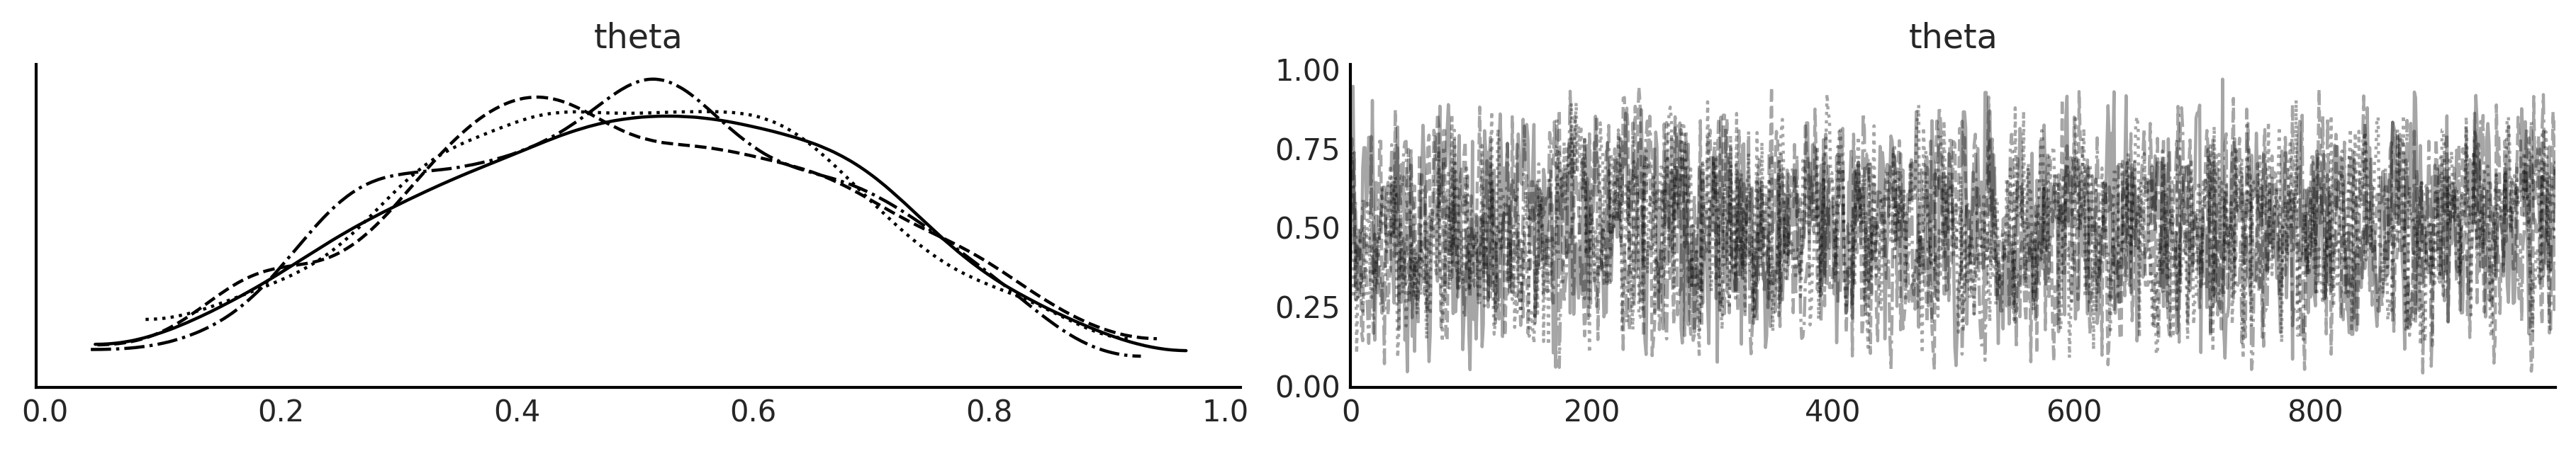

In [5]:
az.plot_trace(idata)
plt.savefig

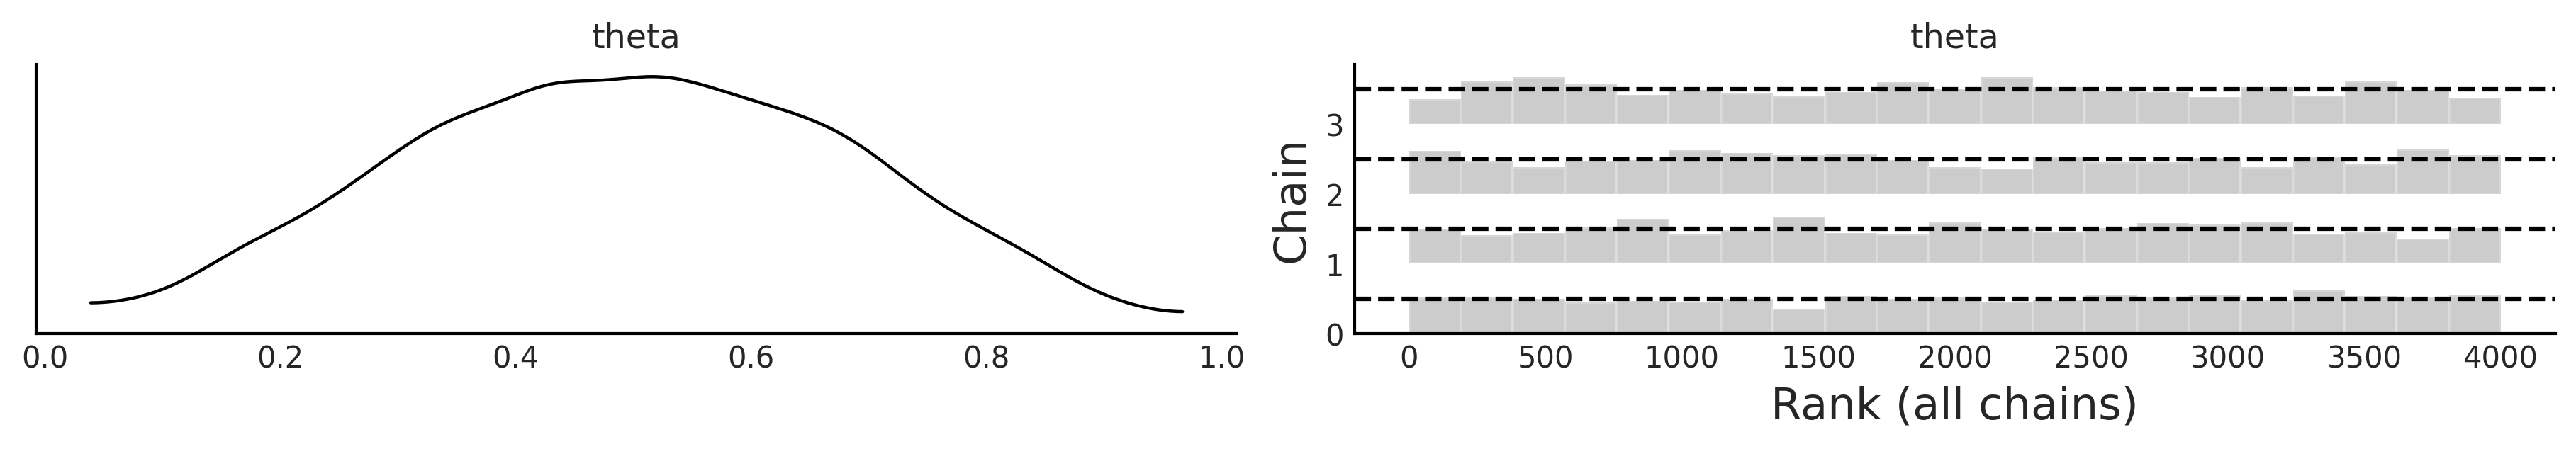

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True, rank_kwargs={'colors': 'k'})
plt.savefig('fig/idata_rank.png')

In [7]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
theta,0.5,0.18,0.16,0.84


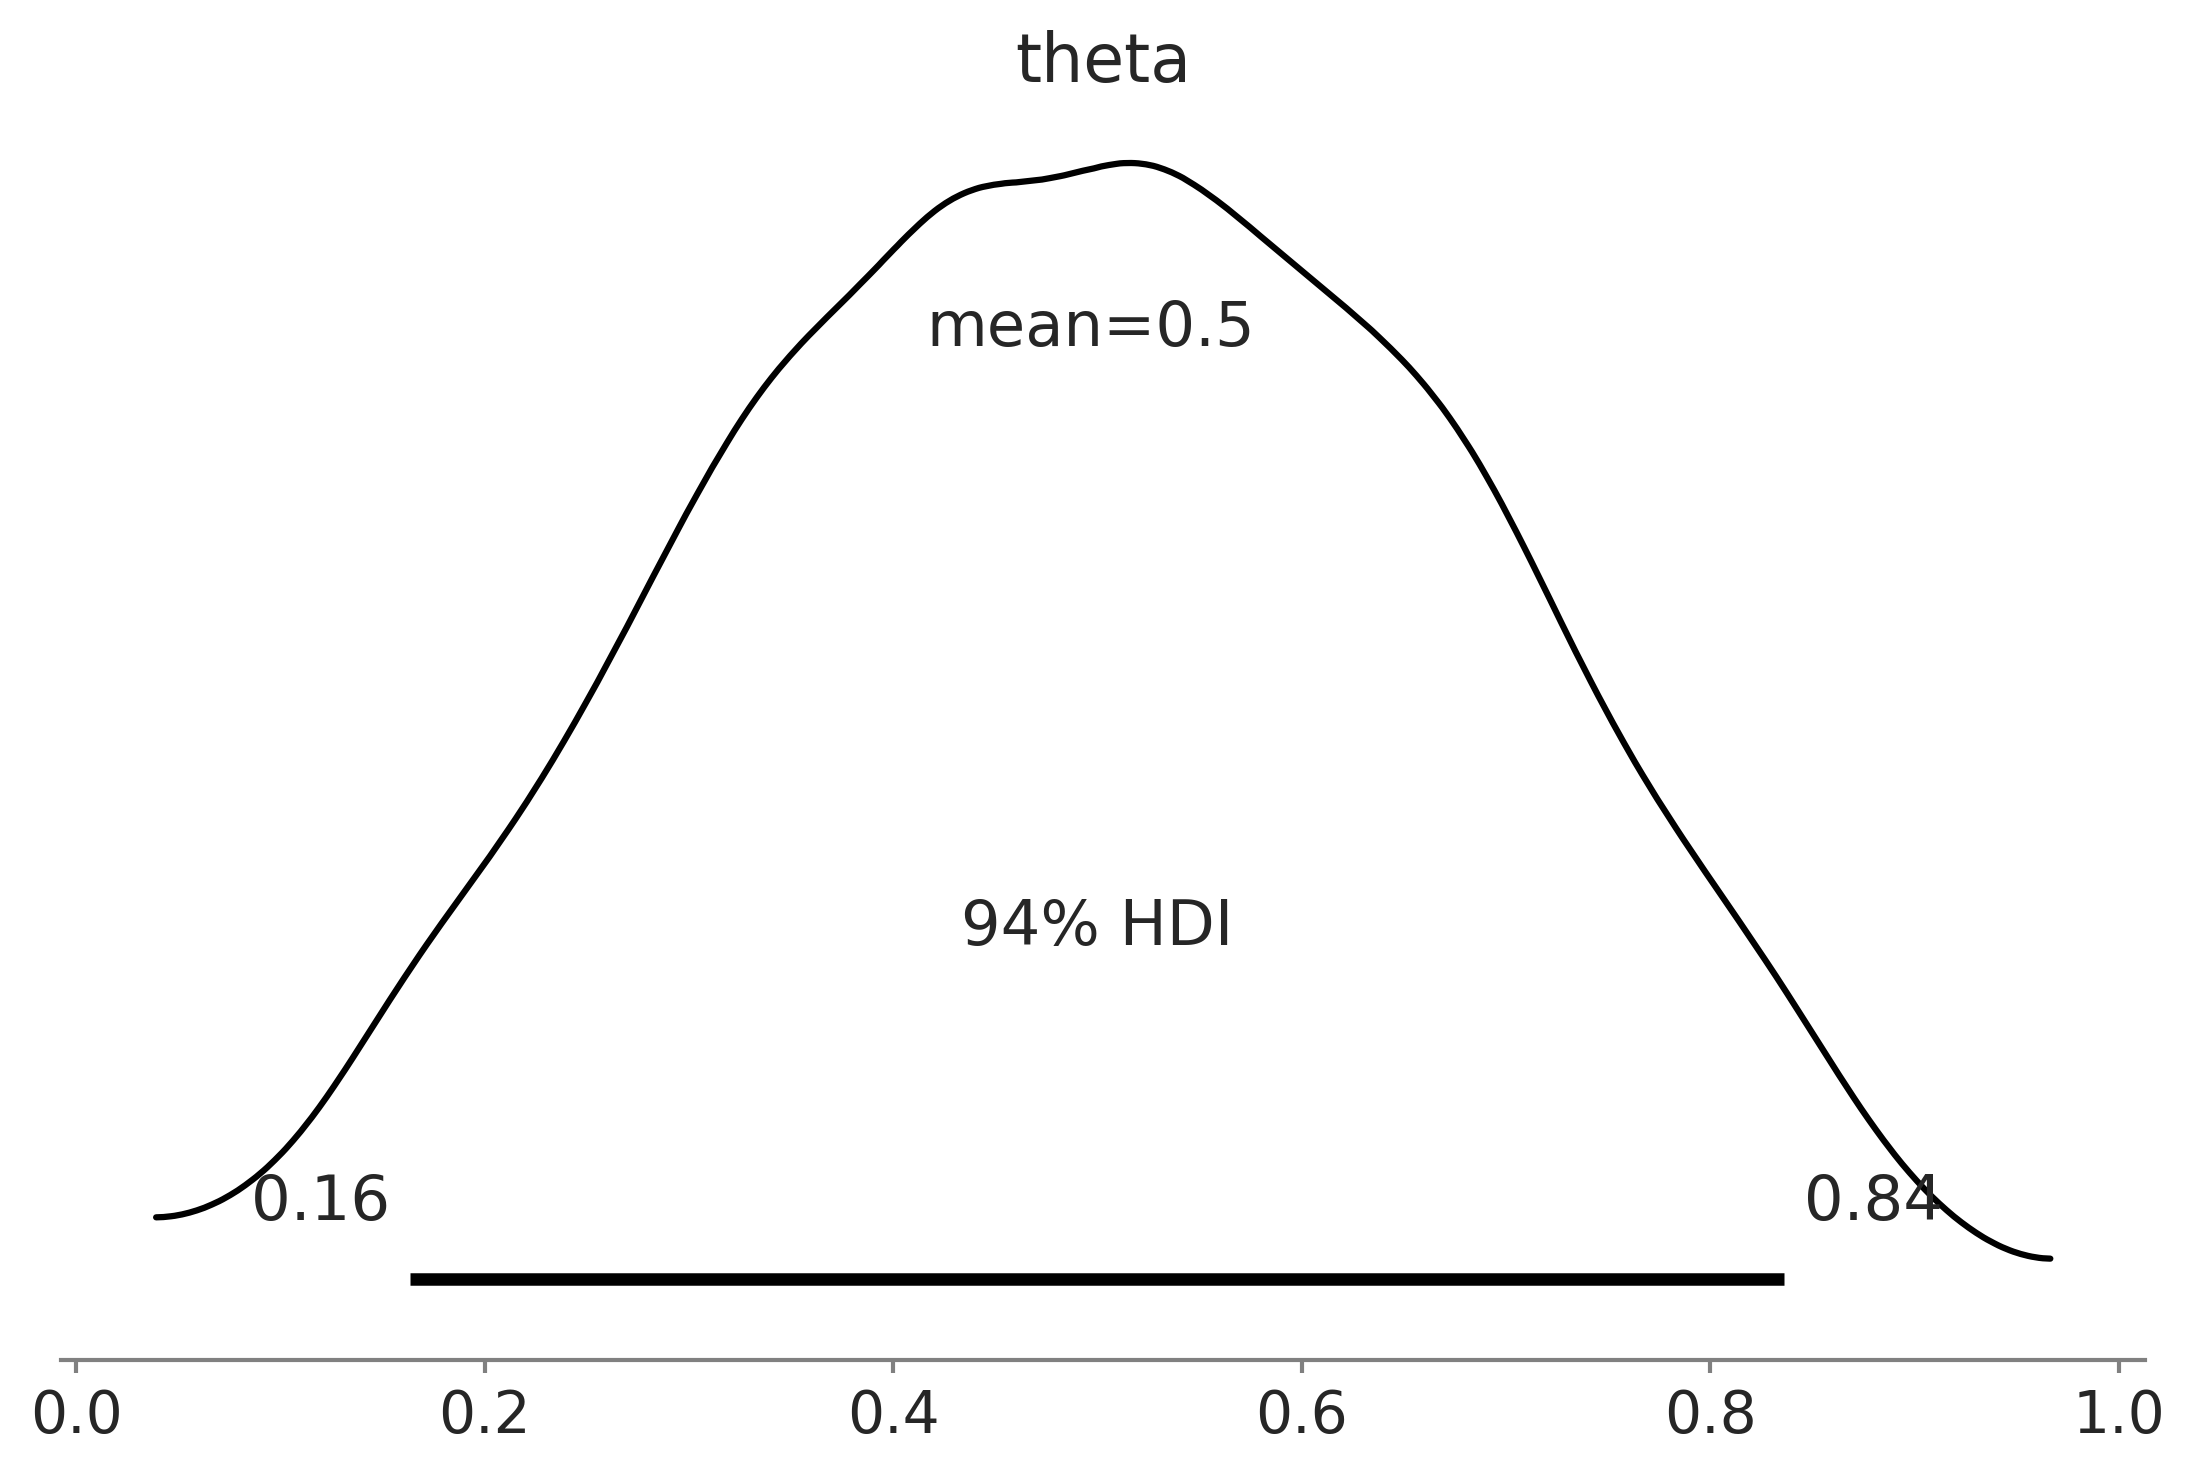

In [8]:
az.plot_posterior(idata)
plt.savefig('fig/idata_posterior.png')

In [9]:
az.plot_bf(idata, var_name='θ', prior=np.random.uniform(0, 1, 10000), ref_val=0.5)
plt.savefig('fig/idata_bf.png')

KeyError: 'var names: "[\'θ\'] are not present" in dataset'

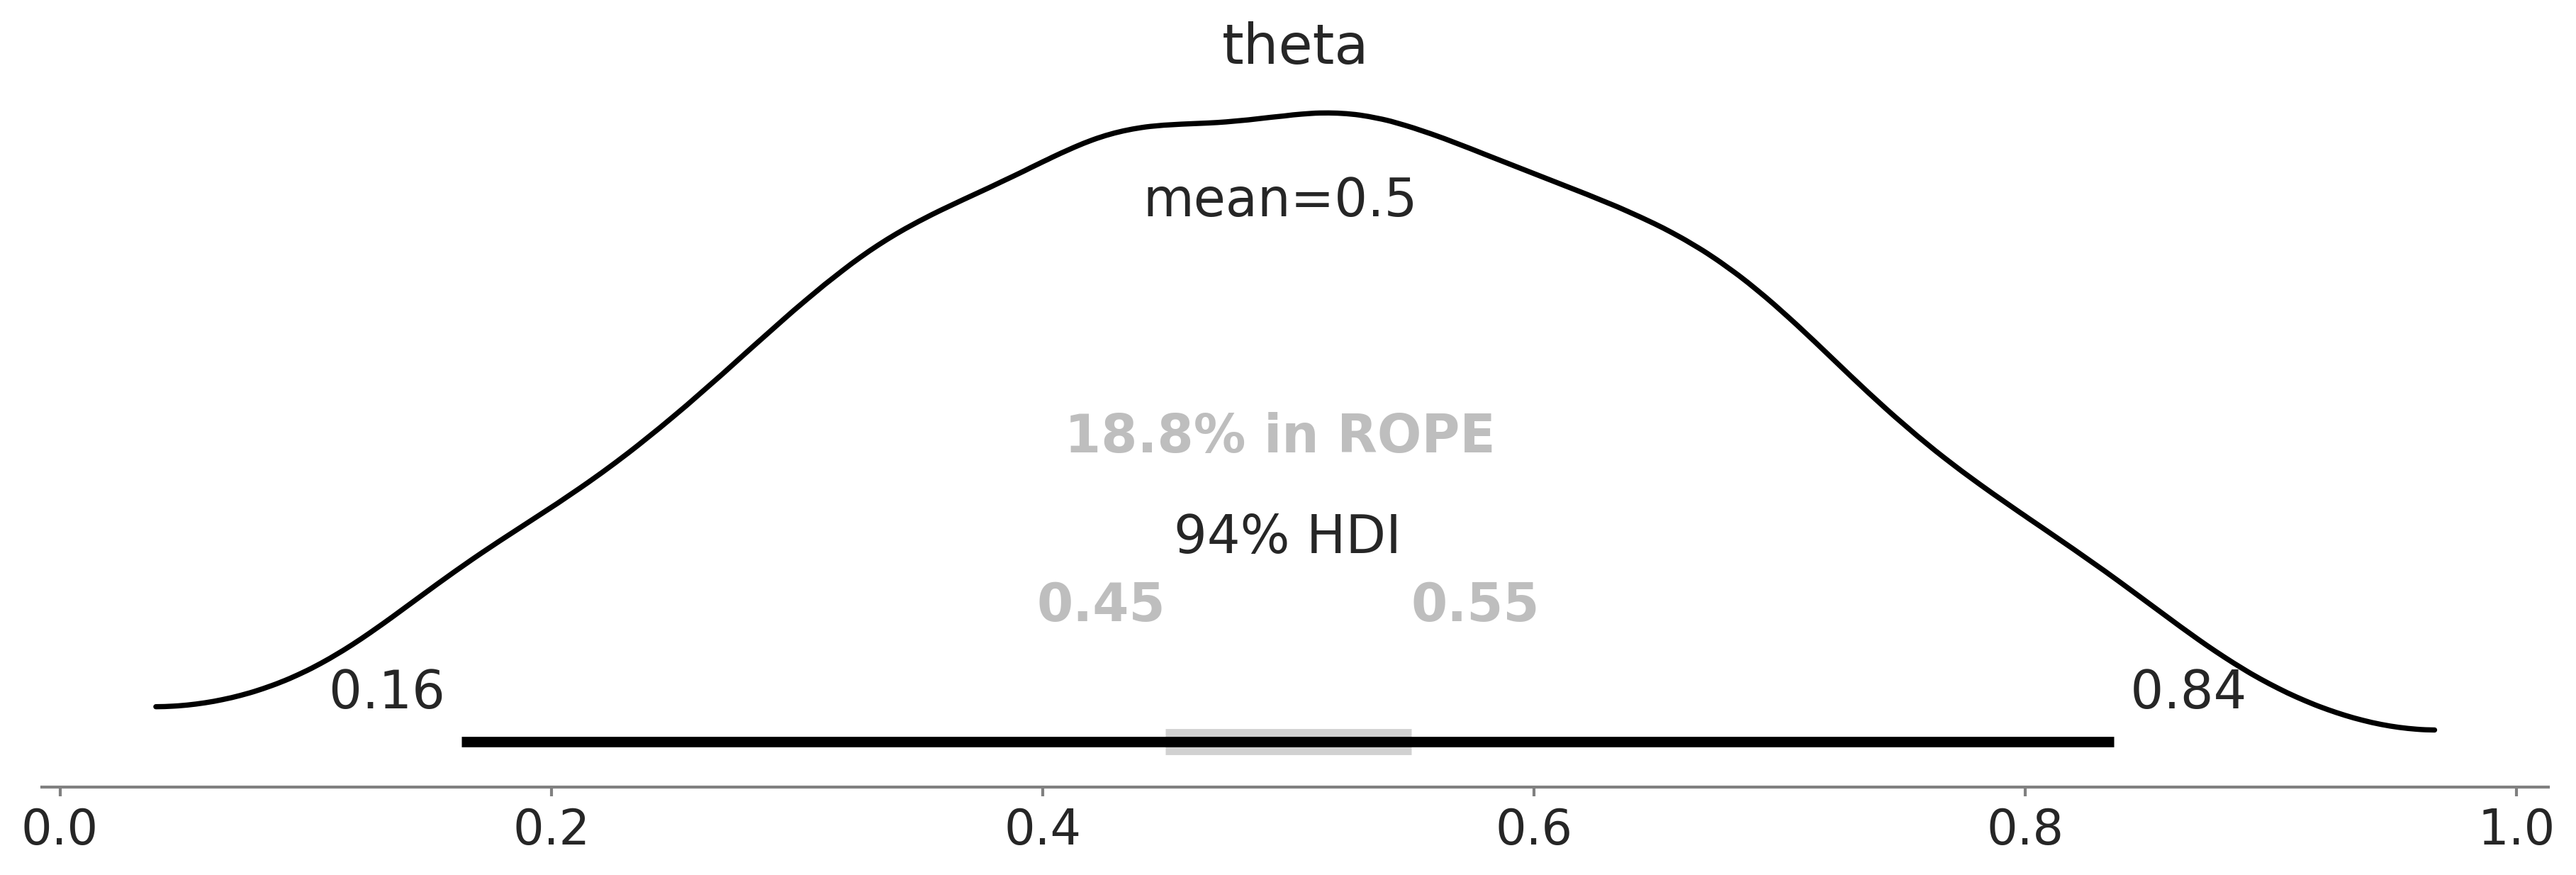

In [10]:
az.plot_posterior(idata, rope=[0.45, 0.55], figsize=(12, 4))
plt.savefig('fig/idata_posterior_rope.png')

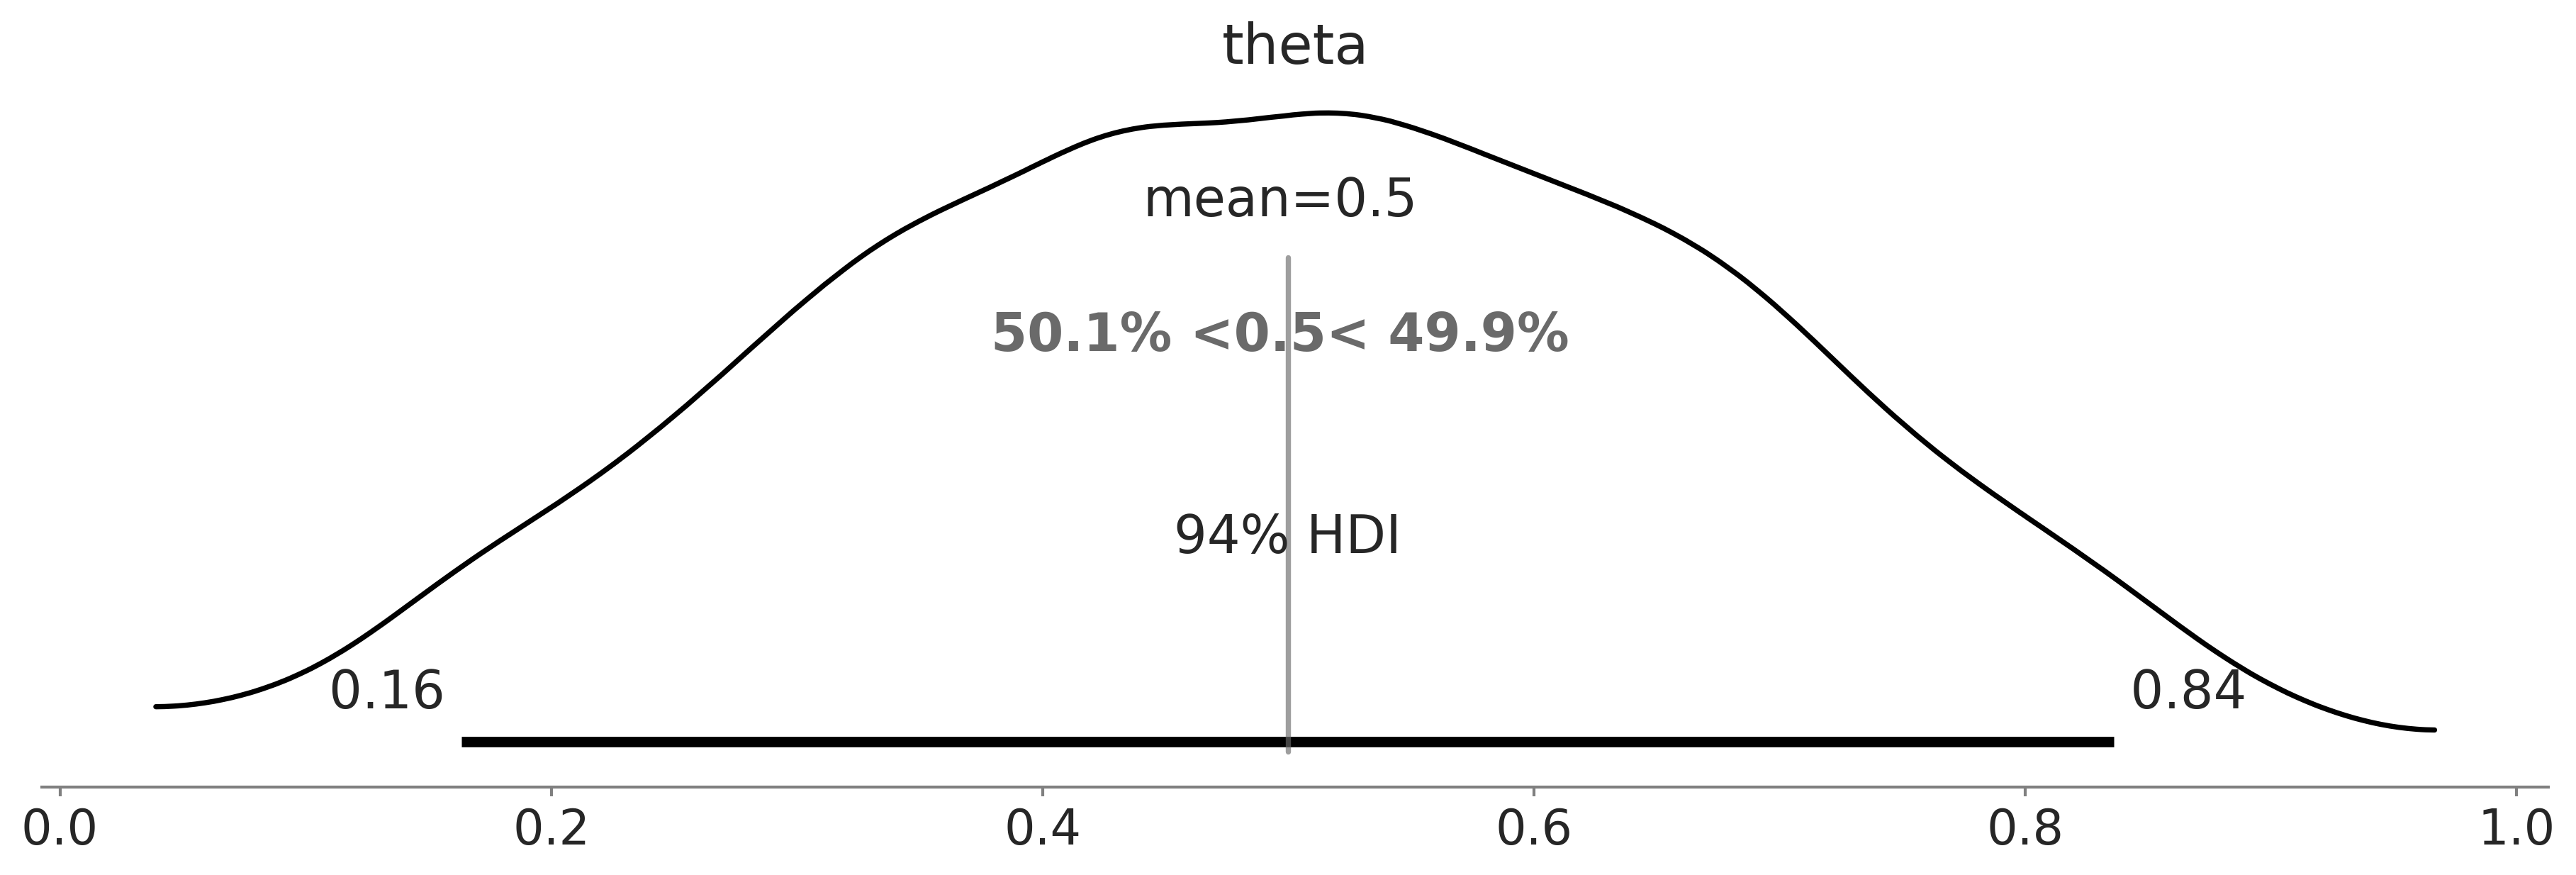

In [11]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/udata_posterior_ref.png')

In [12]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]
np.argmin(lossf_a)

99

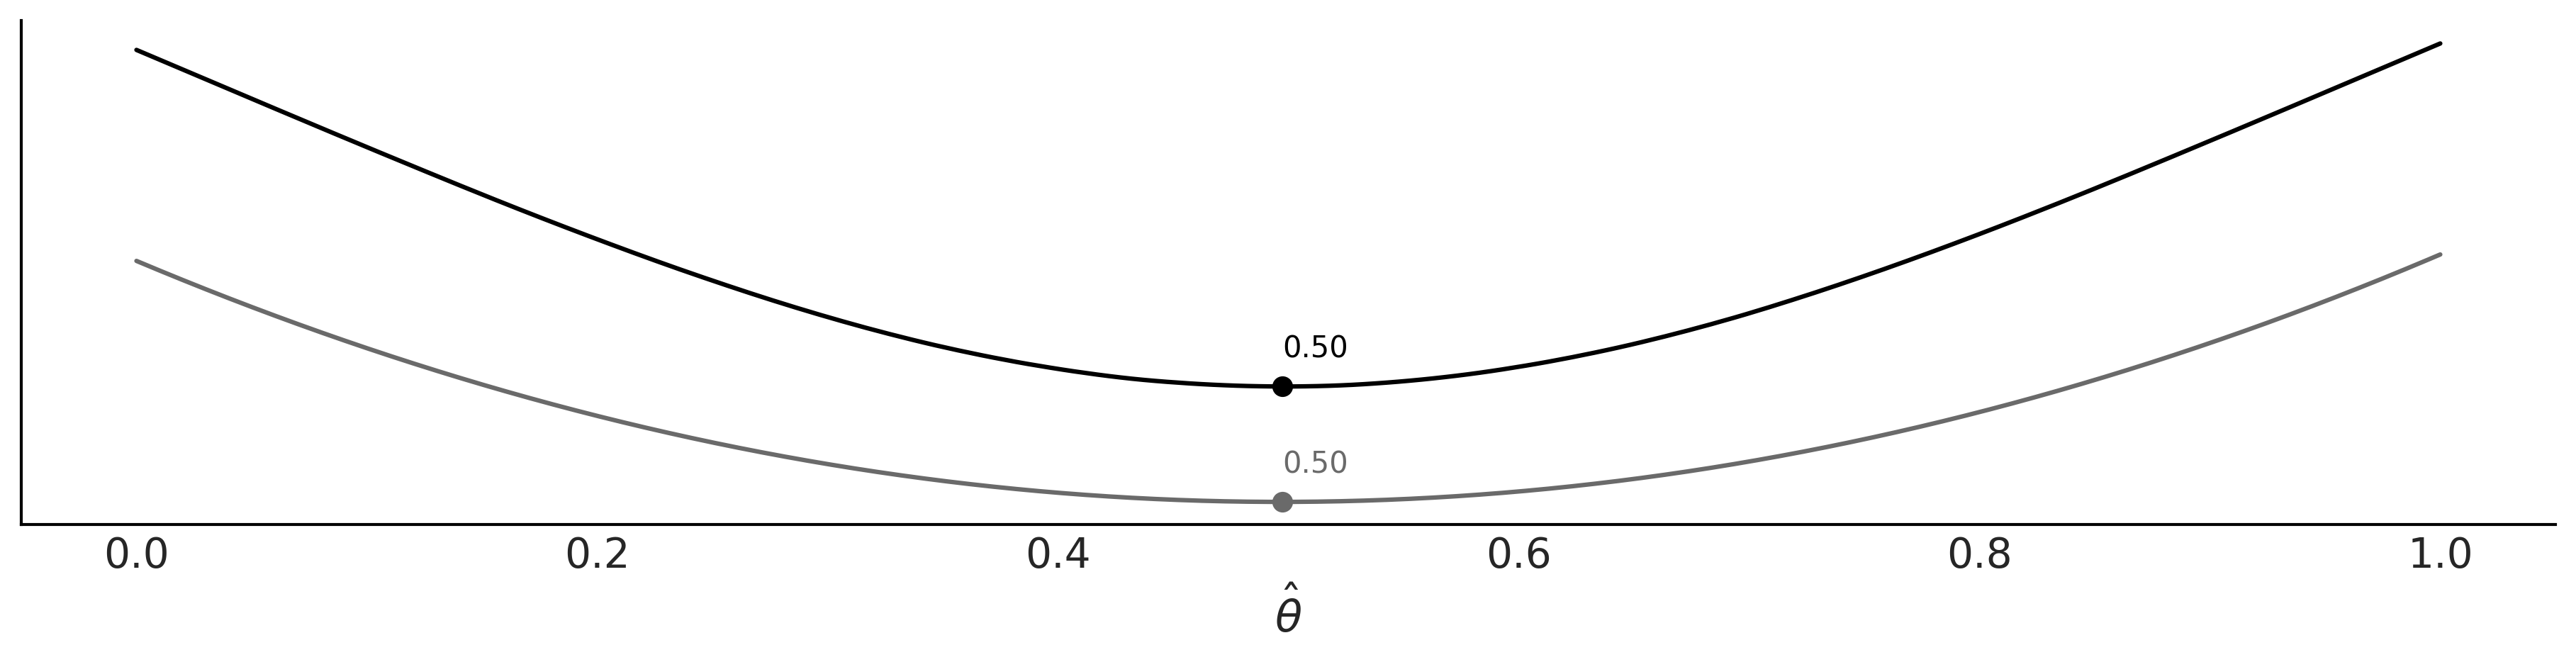

In [15]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]

_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini], lossf[mini] + 0.03), color=c)
    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss.png')